In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
ds = pd.read_csv("Linear_Regre_Scratch/Salary_Data.csv")
X = ds["YearsExperience"].values
Y= ds["Salary"].values

In [12]:
X


array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [13]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

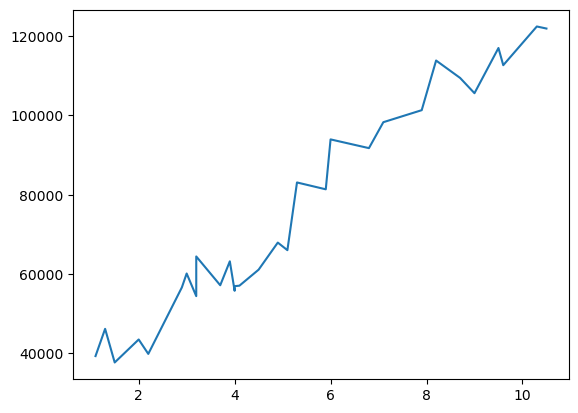

In [14]:
plt.plot(X,Y)

In [15]:
def mean(X):
    return np.sum(X)/len(X)

In [16]:
def variance(X):
    mean_value= mean(X)
    return np.sum((X-mean_value)**2)/len(X)

In [21]:
def norm(X):
    mean_value = mean(X)
    variance_value = variance(X)
    return (X-mean_value)/np.sqrt(variance_value)

In [23]:
X_norm = norm(X)
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

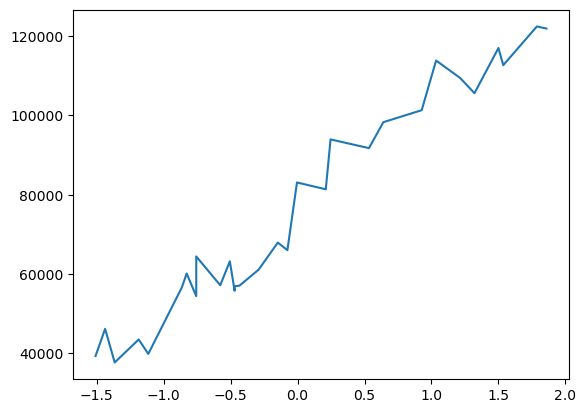

In [30]:
plt.plot(X_norm, Y)
import random

In [44]:
class SimpleLR:
    def __init__(self,lr=0.1, max_iter=2700, threshold= 1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)

    def predict(self,X):
        return self.weight*X + self.bias
        
    def fit(self,X,Y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors = Y- y_pred
        prev_loss = (1/(2*n))* np.sum(errors**2)
        for i in range(self.max_iter):
            w_grad = (1/n) * np.sum(errors*X)
            b_grad = (1/n) * np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors = Y-y_pred
            curr_loss = (1/(2*n)) * np.sum(errors**2)
            if np.abs(curr_loss-prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history
    def plot(self,X,Y):
        y_pred = self.predict(X)
        plt.plot(X,Y)
        plt.plot(X,y_pred)
            

In [45]:
model = SimpleLR()

In [46]:
loss_history = model.fit(X_norm,Y)

In [47]:
loss_history

[np.float64(2636610750.3749604),
 np.float64(2138625448.2173343),
 np.float64(1735257353.4696577),
 np.float64(1408529196.724039),
 np.float64(1143879389.7600887),
 np.float64(929513046.1192883),
 np.float64(755876307.7702404),
 np.float64(615230549.7075114),
 np.float64(501307485.67670095),
 np.float64(409029803.8117444),
 np.float64(334284881.50112975),
 np.float64(273741494.42953175),
 np.float64(224701350.90153742),
 np.float64(184978834.6438619),
 np.float64(152803596.47514486),
 np.float64(126741653.55848394),
 np.float64(105631479.79598866),
 np.float64(88532239.04836752),
 np.float64(74681854.04279433),
 np.float64(63463042.18828005),
 np.float64(54375804.58612351),
 np.float64(47015142.12837669),
 np.float64(41053005.5376018),
 np.float64(36223674.89907414),
 np.float64(32311917.081866752),
 np.float64(29143393.24992877),
 np.float64(26576888.946059007),
 np.float64(24498020.459924508),
 np.float64(22814136.986155562),
 np.float64(21450191.372402705),
 np.float64(20345395.4252

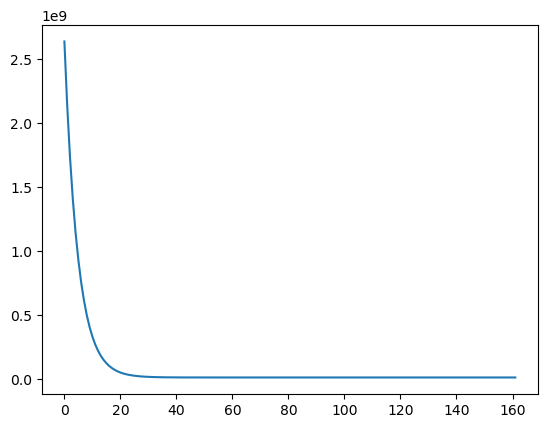

In [48]:
plt.plot(loss_history)

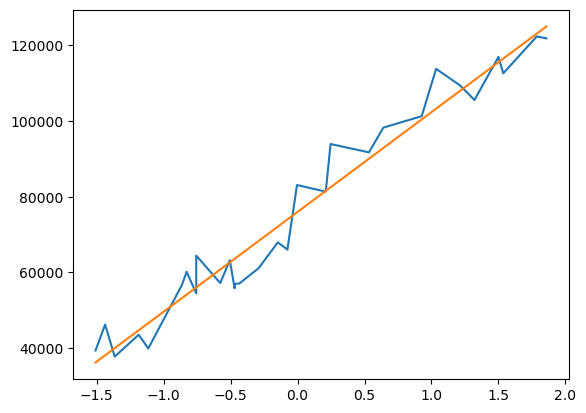

In [49]:
model.plot(X_norm,Y)